In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import glob


In [2]:
def convert_img_to_array(x):
    x = np.asarray(x)
    while x.dtype == object:
        x = np.asarray(x.item() if x.ndim == 0 else x[0])
    return x

In [25]:
# regions_df = pd.read_csv('../20260617_darkfield_data_for_NN.csv')
# regions_df
df = pd.read_pickle('../20260617_darkfield_data_for_NN.pkl')
df

,,Area,ImageX,ImageY,Intensity_gfp,Array_gfp,Intensity_abs,Array_abs,Grew
Region,View,,,,,,,,
0,1,180.0,5.894444,5.894444,921.655556,"[[942, 892, 1020, 987, 1002, 965, 939, 921, 10...",0.138163,"[[0.116433874, 0.09903811, 0.11986743, 0.09132...",False
1,1,278.0,9.676259,2953.194245,992.359712,"[[928, 902, 924, 984, 967, 1002, 970, 992, 110...",-0.032486,"[[-0.06998746, -0.0208492, -0.035817664, -0.02...",False
2,1,346.0,186.500000,210.500000,957.112717,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 983, 0, 0, ...",-0.000368,"[[0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, -0.0, -...",False
3,1,241.0,217.547718,4.854772,945.892116,"[[0, 0, 943, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [8...",0.015796,"[[-0.0, -0.0, 0.00512503, 0.0, -0.0, -0.0, -0....",False
4,1,387.0,251.470284,468.180879,1028.870801,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1121, 0, 0, 0,...",0.055115,"[[0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, -0.0, 0...",False
...,...,...,...,...,...,...,...,...,...
24,14,981.0,537.608563,568.349643,1032.898063,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0.379113,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",False
25,14,1021.0,577.830558,2953.486778,974.387855,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 99...",-0.042277,"[[-0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0....",False
26,14,559.0,562.588551,344.057245,1003.220036,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 88...",0.370344,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",False


In [37]:
class Ds(Dataset):
    def __init__(self, annotations_file, transform=None, target_transform=None):
        self.img_labels = pd.read_pickle(annotations_file)
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        image = self.img_labels.iloc[idx, 6]
        gfp_label = self.img_labels.iloc[idx, 3]
        dark_label = self.img_labels.iloc[idx, 5]
        area_label = self.img_labels.iloc[idx, 0]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, dark_label, area_label, gfp_label

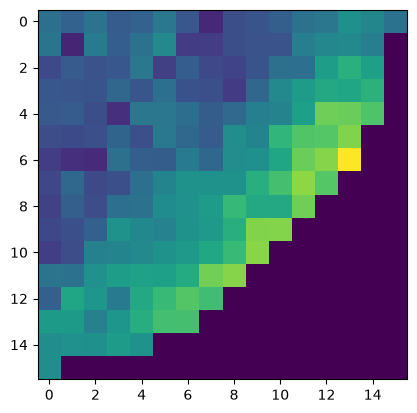

In [39]:
#manual testing
ds = Ds('../20260617_darkfield_data_for_NN.pkl')
ex = ds[0]
plt.imshow(ex[0])